Train a Neural Network on FAOStat data
---

This jupyter notebook shows how to train a neural network on FAOStat data. This notebook essentially details the steps taken in the `train.py` file, which can be used to train a family of neural networks in parallel. However, we also show how the training data is generated from the original (pooled) FAOStat data.


In [9]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
import xarray as xr

import nn as base
import plot_utils as putils

from ruamel.yaml import YAML

page_width = 6.8246

yaml = YAML(typ='safe')
device = 'cpu'
torch.set_default_device(device)

## 1. Load the training data

The original datasets are located in `data/FAO_data`. We have pooled the datasets so that countries contributing to 99% of trade a listed explicity, and the remainder subsumed in an `Other` category. We will train on the example of the Soya bean dataset.

In [10]:
# Load in the FAOStat data and convert the coordinates to ISO3 values
FAO_data = xr.open_dataarray(f"data/FAO_data/Soya_beans_pooled_0.99_2000-2022.nc")
FAO_data = FAO_data.assign_coords({
    "Source": [putils.get_iso3(c) for c in FAO_data.coords["Source"].data],
    "Destination": [putils.get_iso3(c) for c in FAO_data.coords["Destination"].data]
})

# Make sure that flows on self-edges are zero (not always the case)
is_loop = xr.DataArray(
    (FAO_data.Source.values[:, None] == FAO_data.Destination.values[None, :]),
    coords={'Source': FAO_data.Source.data, 'Destination': FAO_data.Destination.data},
    dims=['Source', 'Destination']
)
is_loop.loc[{"Source": "Other", "Destination": 'Other'}] = False
FAO_data = FAO_data.where(~is_loop, 0)
del is_loop

FAO_data

<xarray.DataArray 'Soya beans' (Reporter: 2, Source: 39, Destination: 74,
                                Element: 2, Year: 23)> Size: 2MB
array([[[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

         [[1.42850000e+05, 4.07420000e+04, 0.00000000e+00, ...,
           5.03140790e+06, 4.58247532e+06, 1.76420000e+06],
          [2.29650000e+04, 5.52500000e+03, 0.00000000e+00, ...,
           1.61835200e+06, 2.13602200e+06, 9.78835000e+05]],

         [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

         ...,

         [[2.81941000e+05, 5.62920000e+05, 8.50580000e+04, ...,
           1.04830000e+04, 2.21168000e+04, 3.20358000e+04],
          [4.75480000e+04, 8.43440000e+04, 1.16700000e+04, ...,
...
          [1.34000000e+02, 9.30000000e+01, 1.81000000e+02, ...,
           2.90000000e+02, 3.25000000e+02, 1.95000000e+02]],

         ...,

         [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

         [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 7.00000000e-02],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

         [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           1.53263800e+04, 2.89799900e+04, 1.76700000e+01],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           8.68000000e+03, 1.83640000e+04, 2.00000000e+01]]]]],
      shape=(2, 39, 74, 2, 23))
Coordinates:
  * Year         (Year) int64 184B 2000 2001 2002 2003 ... 2019 2020 2021 2022
  * Element      (Element) <U15 120B 'Quantity, t' 'Value, 1000 USD'
  * Reporter     (Reporter) <U8 64B 'Exporter' 'Importer'
  * Source       (Source) <U5 780B 'PRY' 'USA' 'ZAF' ... 'TZA' 'NLD' 'Other'
  * Destination  (Destination) <U5 1kB 'DZA' 'ARG' 'AUS' ... 'URY' 'VEN' 'VNM'

We use the `Quantity` variable as the training data. We reshape the `Year` and `Reporter` dimensions into a single `idx` dimension, drop, and transform into a `torch.Tensor`

In [11]:
training_data = torch.from_numpy(
    FAO_data.sel({"Element": "Quantity, t"}).stack({'idx': ['Year', 'Reporter']}).drop_vars(['Year', 'Reporter']).transpose('idx', ...).data
).float().to(device)

M, N = training_data.shape[1:]

Next, we calculate the marginals by taking the maximum reported value for each edge.

In [12]:
mu = FAO_data.sel({"Element": "Quantity, t"}, drop=True).sum('Destination', skipna=True)
mu.loc[{"Reporter": "Exporter"}] = mu.max('Reporter')
mu.loc[{"Reporter": "Importer"}] = mu.max('Reporter')
mu = mu.stack({"idx": ['Year', 'Reporter']}).drop_vars(['Year', 'Reporter']).transpose('idx', ...).data
mu = torch.from_numpy(mu).float().reshape(-1, M, 1)

nu = FAO_data.sel({"Element": "Quantity, t"}, drop=True).sum('Source', skipna=True)
nu.loc[{"Reporter": "Exporter"}] = nu.max('Reporter')
nu.loc[{"Reporter": "Importer"}] = nu.max('Reporter')
nu = nu.stack({"idx": ['Year', 'Reporter']}).drop_vars(['Year', 'Reporter']).transpose('idx', ...).data
nu = torch.from_numpy(nu).float().reshape(-1, 1, N)

We now calculate the mask for each training dset. The mask blends out zero-edges for which values have been reported on other datasets (e.g. by other reporters, or on the `Value` variable). If all exporter-reported and the importer-reported values are 0 (including on `Value`), we do not mask that value, but rather constrain the cost matrix to be 1 on that edge.

In [13]:
# Mask that constrains the cost matrix to be 1. We require the cost matrix to be 1 on edges that are zero across all reported values (including Value element)
C_mask = torch.from_numpy((FAO_data == 0).all(dim=['Element', 'Reporter']).expand_dims({"Reporter": ['Exporter', 'Importer']}).stack({'idx': ['Year', 'Reporter']}).drop_vars(['Year', 'Reporter']).transpose('idx', ...).data).bool()

# Target flows: non-zero entries and zeros which are to be mapped to 1
T_mask = torch.logical_or(training_data > 0, C_mask)

We can check that each row and column of each transport plan contains at least one zero which we are mapping to a 1, required for well-posedness.

In [14]:
torch.all(C_mask.any(dim=1)) & torch.all(C_mask.any(dim=-1))

tensor(True)

## 2. Initialise the Neural Network

Next, we create the neural network. We can specify the architecture and activation functions of the neural network -- when using the `train.py` file, this is controlled via the `NeuralNet` key in the `cfg.yaml` file.

In [7]:
NN = base.NeuralNet(
    input_size=M * N,
    output_size=M * N,
    num_layers=5,
    nodes_per_layer=dict(default=60),
    activation_funcs=dict(default='tanh', layer_specific={-1: 'sigmoid'}),
    biases=dict(default=None),
    optimizer='Adam',
    learning_rate=0.002
).to(device)

loss_dict = {
    'training_loss': [], 'regularisation_error': [], 'prediction_error': [], 'test_error': []
}

## 3. Train
Next, we train the network on the data. We specify the epsilon regularisation parameter as well as the other Sinkhorn keyword arguments.

In [8]:
# Kwargs for the Sinkhorn algorithm: maximum number of iterations, precision tolerance criterion for termination, and whether to normalise one of the scaling vectors
sinkhorn_kwargs = dict(max_iter=100, tolerance=1e-5, normalise=False)
epsilon = 0.15

In [9]:
# Train
num_epochs = 10
batch_size = 23

# Scaling for training loss
eta = 1

# Train
for it in (pbar := tqdm(range(num_epochs))):

    # Track the epoch errors
    epoch_training_loss = []
    epoch_accuracy = []
    epoch_regularisation_error = []

    # Initialise the loss
    loss = torch.tensor(0.0, requires_grad=True)
    for j, dset in enumerate(training_data):

        # Make a prediction
        _C_pred = NN(dset.reshape(M * N, )).reshape(M, N)

        # Get the marginals from the predicted cost matrix
        m, n = base.Sinkhorn(
            mu[j],
            nu[j],
            _C_pred,
            epsilon=epsilon,
            **sinkhorn_kwargs,
        )

        _, _, _T_pred = base.marginals_and_transport_plan(m, n, _C_pred, epsilon=epsilon)

        # Track the accuracy
        epoch_accuracy.append(torch.masked_select(abs(_T_pred.clone().detach() - dset), T_mask[j]))

        # Training loss = L2 loss on non-zero edges
        training_loss = torch.nn.functional.mse_loss(
            torch.masked_select(_T_pred, T_mask[j]),
            torch.masked_select(dset, T_mask[j])
        )
        epoch_training_loss.append(training_loss.clone().detach())

        # Regulariser: cost matrix is 1 on zero-flow edges
        regularisation_err = torch.nn.functional.mse_loss(
            torch.masked_select(_C_pred, C_mask),
            torch.ones_like(torch.masked_select(_C_pred, C_mask))
        )
        epoch_regularisation_error.append(regularisation_err.clone().detach())

        # Sum the loss
        loss = loss + training_loss + eta * regularisation_err

        # Perform a gradient descent step every B iterations
        if j > 0 and (j % batch_size == 0 or j == training_data.shape[0] - 1):
            loss.backward()
            NN.optimizer.step()
            NN.optimizer.zero_grad()
            loss = torch.tensor(0.0, requires_grad=True)

    loss_dict['training_loss'].append(np.mean(epoch_training_loss))
    loss_dict['regularisation_error'].append(np.mean(epoch_regularisation_error))
    loss_dict['prediction_error'].append(torch.cat(epoch_accuracy).mean().item())

    pbar.set_description(f"Loss: {loss_dict['training_loss'][-1]:>.4g}, Regularisation: {loss_dict['regularisation_error'][-1]:>.4g}, L1 prediction error: {loss_dict['prediction_error'][-1]:>.4g}")

Loss: 8.575e+09, Regularisation: 0.3183, L1 prediction error: 1.371e+04: 100%|██████████| 10/10 [00:03<00:00,  3.32it/s]


We can plot the loss (we are not using any data as a test set, so that entry will be empty):

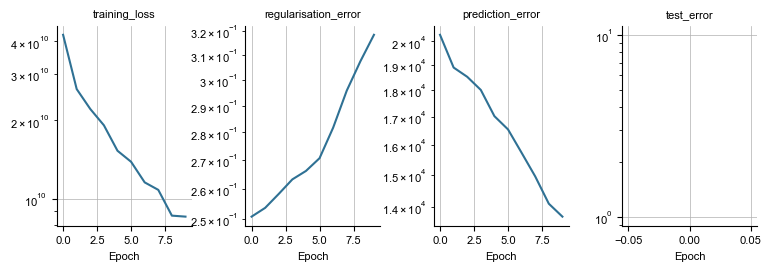

In [17]:
fig, axs = plt.subplots(ncols=len(loss_dict.keys()), figsize=(7, 2), gridspec_kw={'wspace': 0.4})
for idx, (k, v) in enumerate(loss_dict.items()):
    axs[idx].plot(v)
    axs[idx].set_title(k)
    axs[idx].set_xlabel("Epoch")
    axs[idx].set_yscale('log')

## 4. Sample

Repeating the above several times for different neural networks generates an ensemble distribution on the cost matrix. Additionally, we can randomly picking one of the reporter values for each Year, where available, and push this transport plan sample through the trained networks. We generate 1000 samples for each of the 20 years by pushing 100 different transport plans through 10 trained neural networks. The individual models are located in the `trained_models` folders of each commodity.

In [17]:
def generate_samples(dir, model_dir, *, N_samples, show_pbar: bool = True, pbar = None, rep: str = None) -> xr.DataArray:
    """ Generates samples using a single trained model.

    :param dir: directory of the training data
    :param model_dir: directory of the trained network
    :param N_samples: number of samples
    :return: xr.DataArray of samples
    """
    _FAO_data = xr.open_dataarray(f"{dir}/FAO_data_pooled.nc")
    _training_data = torch.load(f"{dir}/training_T.pt")
    _training_mu = torch.load(f"{dir}/training_mu.pt")
    _training_nu = torch.load(f"{dir}/training_nu.pt")
    M, N = _training_data.shape[1:]

    _empty = np.zeros((N_samples, len(_FAO_data.coords['Year'].data), M, N))
    _samples = xr.Dataset(
        data_vars=dict(
            C=(["Sample", "Year", "Source", "Destination"], np.zeros_like(_empty)),
            T=(["Sample", "Year", "Source", "Destination"], np.zeros_like(_empty)),
            T_pred=(["Sample", "Year", "Source", "Destination"], np.zeros_like(_empty))
        ),
        coords={"Sample": np.arange(N_samples),
                "Year": _FAO_data.coords["Year"].data,
                "Source": _FAO_data.coords["Source"].data,
                "Destination": _FAO_data.coords["Destination"].data}
    )
    with open(f"{model_dir}/cfg.yaml") as file:
        _cfg = yaml.load(file)
    _NN = base.NeuralNet(
        input_size=M * N,
        output_size=M * N,
        **_cfg['NeuralNet']
    )
    _NN.load_state_dict(torch.load(f"{model_dir}/model_trained.pt"))
    _NN.eval()

    _sinkhorn_kwargs = _cfg['Training']['sinkhorn_kwargs']

    for j in tqdm(range(N_samples), desc="Sampling") if show_pbar else range(N_samples):

        for i, year in enumerate(_FAO_data.coords['Year'].data):

            # Pick random entries along the 'Reporter' axis, if no reporter specified, and fill NaN values
            if rep is None:
                _dset = torch.from_numpy(
                    np.apply_along_axis(np.random.choice, 0, _FAO_data.sel({"Element": "Quantity, t", "Year": year}).data)
                ).float()
            else:
                _dset = torch.from_numpy(
                    _FAO_data.sel({"Element": "Quantity, t", "Year": year, "Reporter": rep}).data
                ).float()

            _C_pred = _NN(_dset.reshape(M * N, )).reshape(M, N).detach()

            # Get the marginals from the predicted cost matrix
            m, n = base.Sinkhorn(
                _dset.sum(dim=1, keepdim=True),
                _dset.sum(dim=0, keepdim=True),
                _C_pred,
                **_sinkhorn_kwargs,
            )

            _, _, _T_pred = base.marginals_and_transport_plan(m, n, _C_pred, epsilon=_sinkhorn_kwargs['epsilon'])

            _samples["C"].loc[{"Year": year, "Sample": j}] = _C_pred
            _samples["T"].loc[{"Year": year, "Sample": j}] = _dset
            _samples["T_pred"].loc[{"Year": year, "Sample": j}] = _T_pred
        if pbar is not None:
            pbar.update(1)
    return _samples

In [23]:
samples = []
N_samples = 5
dir = "data/Soya"
for i, model_dir in enumerate(os.listdir(f"{dir}/trained_models")):
    if not model_dir.startswith("."):
        samples.append(
            generate_samples("data/Soya", f"{dir}/trained_models/{model_dir}", N_samples=N_samples).assign_coords({"Sample": np.arange(N_samples*i, N_samples*i+N_samples)})
        )
samples = xr.concat(samples, dim='Sample')

Sampling: 100%|██████████| 5/5 [00:01<00:00,  4.13it/s]


We can visualise the results on a collection of edges:

[Text(0, 0.5, 'Cost statistics')]

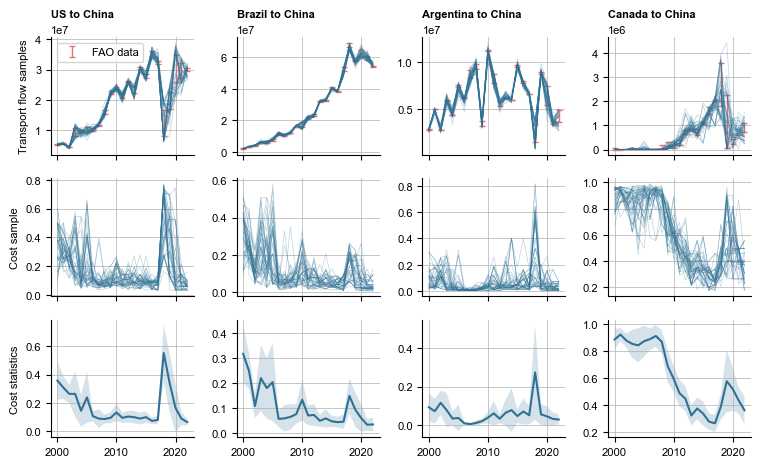

In [24]:
fig, axs = plt.subplots(ncols=4, nrows=3, sharex=True, gridspec_kw={'wspace': 0.3}, figsize=(7, 4))
for idx, e in enumerate([('USA', 'CHN'), ('BRA', 'CHN'), ('ARG', 'CHN'), ('CAN', 'CHN')]):

    _d = samples["T"].sel({"Source": e[0], "Destination": e[1]})
    _x = _d.coords['Year']

    _y = FAO_data.sel({"Element": "Quantity, t", "Source": e[0], "Destination": e[1]})
    axs[0, idx].errorbar(_x, _y.mean('Reporter'), _y.std('Reporter'), lw=0, elinewidth=1, capsize=2, c='C1', label='FAO data')
    axs[0, 0].legend()

    samples["T_pred"].sel({"Source": e[0], "Destination": e[1]}).plot(ax=axs[0, idx], hue='Sample', add_legend=False, c='C0', lw=0.5, alpha=0.3)

    samples["C"].sel({"Source": e[0], "Destination": e[1]}, drop=True).plot(ax=axs[1, idx], hue='Sample', add_legend=False, c='C0', lw=0.5, alpha=0.3)

    _d = samples["C"].sel({"Source": e[0], "Destination": e[1]})
    _x = _d.coords['Year']

    e1 = axs[2, idx].fill_between(_x, _d.mean('Sample') - _d.std('Sample'), _d.mean('Sample')+_d.std('Sample'), alpha=0.2)
    m1 = axs[2, idx].plot(_x, _d.mean('Sample'))

    axs[0, idx].set_title(f"{putils.property_from_iso3(e[0], item='Name')} to {putils.property_from_iso3(e[1], item='Name')}", y=1.1, x=0.0, ha='left', fontweight='bold')

for ax in axs.flatten():
    ax.set(xlabel='', ylabel='')

axs[0, 0].set(ylabel='Transport flow samples')
axs[1, 0].set(ylabel='Cost sample')
axs[2, 0].set(ylabel='Cost statistics')

We only save the sample statistics (mean and standard deviation) to the respective folders.

# 5. Prepare batch training data

In [15]:
for _source in ["Barley", "Beef", "Wine", "Wheat", ("Dairy", "Dairy_all"), ("Sugar", "Sugar_products"), "Corn", "Tomatoes", ("Soya", "Soya_beans"), ("Lettuce", "Vegetables"), ("Cucumbers", "Cucumbers_and_gherkins")]:
    if isinstance(_source, tuple):
        _name, _source = _source
    else:
        _name = _source
    FAO_data = xr.open_dataarray(f"data/FAO_Data/{_source}_pooled_0.99_2000-2022.nc")
    FAO_data = FAO_data.assign_coords({
        "Source": [putils.get_iso3(c) for c in FAO_data.coords["Source"].data], "Destination": [putils.get_iso3(c) for c in FAO_data.coords["Destination"].data]
    })
    is_loop = xr.DataArray(
        (FAO_data.Source.values[:, None] == FAO_data.Destination.values[None, :]),
        coords={'Source': FAO_data.Source.data, 'Destination': FAO_data.Destination.data},
        dims=['Source', 'Destination']
    )
    is_loop.loc[{"Source": "Other", "Destination": 'Other'}] = False
    FAO_data = FAO_data.where(~is_loop, 0)
    training_data = torch.from_numpy(
        FAO_data.sel({"Element": "Quantity, t"}).stack({'idx': ['Year', 'Reporter']}).drop_vars(['Year', 'Reporter']).transpose('idx', ...).data
    ).float().to(device)

    M, N = training_data.shape[1:]
    mu = FAO_data.sel({"Element": "Quantity, t"}, drop=True).sum('Destination', skipna=True)
    mu.loc[{"Reporter": "Exporter"}] = mu.max('Reporter')
    mu.loc[{"Reporter": "Importer"}] = mu.max('Reporter')
    mu = mu.stack({"idx": ['Year', 'Reporter']}).drop_vars(['Year', 'Reporter']).transpose('idx', ...).data
    mu = torch.from_numpy(mu).float().reshape(-1, M, 1)

    nu = FAO_data.sel({"Element": "Quantity, t"}, drop=True).sum('Source', skipna=True)
    nu.loc[{"Reporter": "Exporter"}] = nu.max('Reporter')
    nu.loc[{"Reporter": "Importer"}] = nu.max('Reporter')
    nu = nu.stack({"idx": ['Year', 'Reporter']}).drop_vars(['Year', 'Reporter']).transpose('idx', ...).data
    nu = torch.from_numpy(nu).float().reshape(-1, 1, N)

    # Mask that constrains the cost matrix to be 1. We require the cost matrix to be 1 on edges that are zero across all reported values
    # (including Value element)
    C_mask = torch.from_numpy((FAO_data == 0).all(dim=['Element', 'Reporter']).expand_dims({"Reporter": ['Exporter', 'Importer']}).stack({'idx': ['Year', 'Reporter']}).drop_vars(['Year', 'Reporter']).transpose('idx', ...).data).bool()

    # Target flows: non-zero entries and zeros which are to be mapped to 1
    T_mask = torch.logical_or(training_data > 0, C_mask)

    # Mask on FAO values
    FAO_mask = ((FAO_data == 0).all(dim=['Element', 'Reporter'])) | ((FAO_data.sel({"Element": "Quantity, t"}, drop=True).mean('Reporter') > 0))

    print(_name, torch.all(C_mask.any(dim=1)) & torch.all(C_mask.any(dim=-1)), N, M)

    # # Save
    # os.makedirs(f"data/{_name}", exist_ok=True)
    # FAO_data.to_netcdf(f"data/{_name}/FAO_data_pooled.nc")
    # FAO_mask.to_netcdf(f"data/{_name}/FAO_data_mask.nc")
    # torch.save(training_data, f"data/{_name}/training_T.pt")
    # torch.save(mu, f"data/{_name}/training_mu.pt")
    # torch.save(nu, f"data/{_name}/training_nu.pt")
    # torch.save(T_mask, f"data/{_name}/T_mask.pt")
    # torch.save(C_mask, f"data/{_name}/C_mask.pt")

Barley tensor(True) 94 51
Beef tensor(True) 123 63
Wine tensor(True) 121 63
Wheat tensor(True) 146 59
Dairy tensor(True) 137 77
Sugar tensor(True) 159 126
Corn tensor(True) 130 66
Tomatoes tensor(True) 89 79
Soya tensor(True) 74 39
Lettuce tensor(True) 116 110
Cucumbers tensor(True) 66 59


# 6. Samples for all commodities
Let us visualise the neural network ensemble predictions only on the importer and exporter-reported datasets.

In [21]:
samples_exp = []
for i in range(1, 11):
    samples_exp.append(
        generate_samples("data/Soya", f"data/Soya/trained_models/model_{i}", N_samples=1, show_pbar=False, rep='Exporter')
    )
samples_exp = xr.concat(samples_exp, dim='Sample')

samples_imp = []
for i in range(1, 11):
    samples_imp.append(
        generate_samples("data/Soya", f"data/Soya/trained_models/model_{i}", N_samples=1, show_pbar=False, rep='Importer')
    )
samples_imp = xr.concat(samples_imp, dim='Sample')

# Now also load the fully sampled data
sample_stats = xr.open_dataset("data/Soya/samples_stats.nc")

[Text(0, 0.5, 'All samples')]

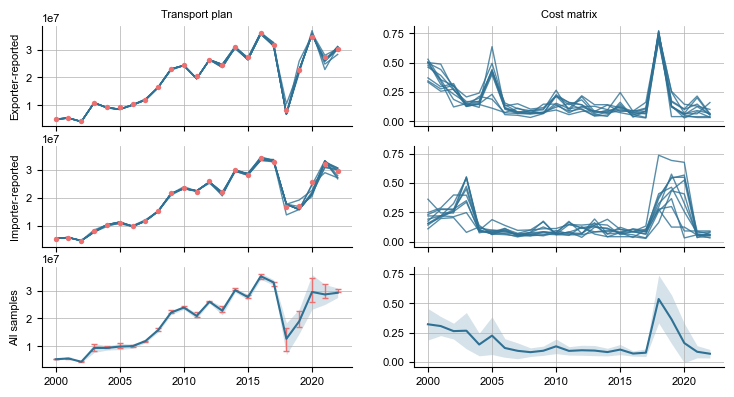

In [22]:
from style import rcParams, colors
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(page_width, page_width*0.5), sharey='col', sharex=True)
samples_exp['T_pred'].sel({"Source": "USA", "Destination": "CHN"}).plot(hue='Sample', ax=axs[0, 0], add_legend=False, lw=1, color=colors['c_darkblue'], alpha=0.8)
samples_exp['C'].sel({"Source": "USA", "Destination": "CHN"}).plot(hue='Sample', ax=axs[0, 1], add_legend=False, lw=1, color=colors['c_darkblue'], alpha=0.8)
samples_exp['T'].sel({"Source": "USA", "Destination": "CHN"}).mean('Sample').plot.scatter(ax=axs[0, 0], c=colors['c_red'], zorder=12, lw=0, s=15)

samples_imp['T_pred'].sel({"Source": "USA", "Destination": "CHN"}).plot(hue='Sample', ax=axs[1, 0], add_legend=False, lw=1, color=colors['c_darkblue'], alpha=0.8)
samples_imp['C'].sel({"Source": "USA", "Destination": "CHN"}).plot(hue='Sample', ax=axs[1, 1], add_legend=False, lw=1, color=colors['c_darkblue'], alpha=0.8)
samples_imp['T'].sel({"Source": "USA", "Destination": "CHN"}).mean('Sample').plot.scatter(ax=axs[1, 0], c=colors['c_red'], zorder=12, lw=0, s=15)

d = sample_stats.sel({"Source": "USA", "Destination": "CHN"})
axs[2, 0].errorbar(
    sample_stats.Year, d.sel({"variable": "T"})['mean'], d.sel({"variable": "T"})['std'], lw=0, capsize=2, elinewidth=1, color=colors['c_red']
)
axs[2, 0].fill_between(
    d.Year, d.sel({"variable": "T_pred"})['mean']-d.sel({"variable": "T_pred"})['std'], d.sel({"variable": "T_pred"})['mean']+d.sel({"variable": "T_pred"})['std'], alpha=0.2, color=colors['c_darkblue'], lw=0
)
d.sel({"variable": "T_pred"})['mean'].plot(ax=axs[2, 0], color=colors['c_darkblue'])

axs[2, 1].fill_between(
    d.Year, d.sel({"variable": "C"})['mean']-d.sel({"variable": "C"})['std'], d.sel({"variable": "C"})['mean']+d.sel({"variable": "C"})['std'], alpha=0.2, color=colors['c_darkblue'], lw=0
)
d.sel({"variable": "C"})['mean'].plot(ax=axs[2, 1], color=colors['c_darkblue'])
for ax in axs.flatten():
    ax.set(title=None, xlabel=None, ylabel=None)
axs[0, 0].set(title="Transport plan", ylabel='Exporter-reported')
axs[0, 1].set_title("Cost matrix")
axs[1, 0].set(ylabel='Importer-reported')
axs[2, 0].set(ylabel='All samples')

#fig.savefig("Images/SI/UQ.pdf", pad_inches=0)

Run this loop to fully re-sample all datasets -- careful: this will take 1-2 hours, depending on your machine.

In [7]:
N_samples = 100

dirs = {}
for dir in os.listdir("data"):
    if not os.path.isdir(f"data/{dir}"):
        continue
    if not "trained_models" in os.listdir(f"data/{dir}"):
        continue
    dirs[f"data/{dir}"] = sorted([f"data/{dir}/trained_models/{p}" for p in os.listdir(f"data/{dir}/trained_models") if os.path.isdir(f"data/{dir}/trained_models/{p}")])

with tqdm(total=sum([len(v) for v in dirs.values()]) * N_samples) as pbar:
    for dir in dirs.keys():
        pbar.set_description(f"{dir.split('/')[-1]}")
        samples = []
        for i, model_dir in enumerate(dirs[dir]):
            samples.append(
                generate_samples(dir, model_dir, N_samples=N_samples, show_pbar=False, pbar=pbar).assign_coords({"Sample": np.arange(N_samples*i, N_samples*i+N_samples)})
            )
        samples = xr.concat(samples, dim='Sample')
        xr.Dataset(dict(mean=samples.to_array().mean("Sample"), std=samples.to_array().std("Sample"))).to_netcdf(f"{dir}/samples_stats.nc")

Beef: 100%|██████████| 1000/1000 [10:35<00:00,  1.57it/s]
